# Neural Network Classification

## 1. Data Understanding

This notebook explores the provided datasets and prepares the selected classification dataset for neural network modeling.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = Path("../data/Datasets.xlsx")

print("Dataset exists:", data_path.exists())

Dataset exists: True


In [3]:
excel_file = pd.ExcelFile(data_path)

print("Available sheets:")
for sheet in excel_file.sheet_names:
    print("-", sheet)

Available sheets:
- Employee_Attrition
- Recruitment
- Resume_NLP
- Recommendation
- Helpdesk
- Bug_Severity
- Churn
- Fraud
- Resource
- Performance


In [4]:
df = pd.read_excel(
    data_path,
    sheet_name="Recruitment"
)

df.head()

,Candidate_ID,Position,Experience,Tech_Score,Interview,Status
0,C0001,DS,4,78,83,Hired
1,C0002,DS,6,99,63,Hired
2,C0003,SE,7,78,69,Rejected
3,C0004,SE,1,89,42,Rejected
4,C0005,QA,4,77,48,Pending


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 200
Number of columns: 6


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Candidate_ID  200 non-null    str  
 1   Position      200 non-null    str  
 2   Experience    200 non-null    int64
 3   Tech_Score    200 non-null    int64
 4   Interview     200 non-null    int64
 5   Status        200 non-null    str  
dtypes: int64(3), str(3)
memory usage: 9.5 KB


In [7]:
df.describe()

,Experience,Tech_Score,Interview
count,200.000000,200.00000,200.00000
mean,4.665000,69.55500,68.99000
std,2.987878,17.81245,16.78986
min,0.000000,40.00000,41.00000
25%,2.000000,54.00000,55.75000
50%,5.000000,71.50000,69.50000
75%,7.000000,84.00000,81.25000
max,10.000000,100.00000,100.00000


In [8]:
df.describe(include="all")

,Candidate_ID,Position,Experience,Tech_Score,Interview,Status
count,200,200,200.000000,200.00000,200.00000,200
unique,200,3,NaN,NaN,NaN,3
top,C0001,QA,NaN,NaN,NaN,Rejected
freq,1,76,NaN,NaN,NaN,69
mean,NaN,NaN,4.665000,69.55500,68.99000,NaN
std,NaN,NaN,2.987878,17.81245,16.78986,NaN
min,NaN,NaN,0.000000,40.00000,41.00000,NaN
25%,NaN,NaN,2.000000,54.00000,55.75000,NaN
50%,NaN,NaN,5.000000,71.50000,69.50000,NaN
75%,NaN,NaN,7.000000,84.00000,81.25000,NaN


In [9]:
df.isnull().sum()

Candidate_ID    0
Position        0
Experience      0
Tech_Score      0
Interview       0
Status          0
dtype: int64

In [10]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df["Status"].value_counts()

Status
Rejected    69
Pending     68
Hired       63
Name: count, dtype: int64

In [13]:
df["Status"].value_counts(normalize=True) * 100

Status
Rejected    34.5
Pending     34.0
Hired       31.5
Name: proportion, dtype: float64

In [14]:
print("Positions:")
print(df["Position"].value_counts())

print("\nStatus:")
print(df["Status"].value_counts())

Positions:
Position
QA    76
SE    68
DS    56
Name: count, dtype: int64

Status:
Status
Rejected    69
Pending     68
Hired       63
Name: count, dtype: int64


### Target Class Distribution

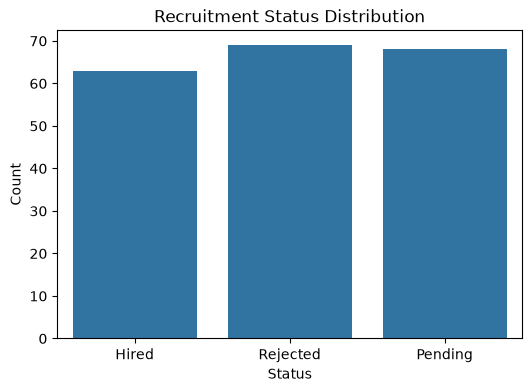

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Status")
plt.title("Recruitment Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

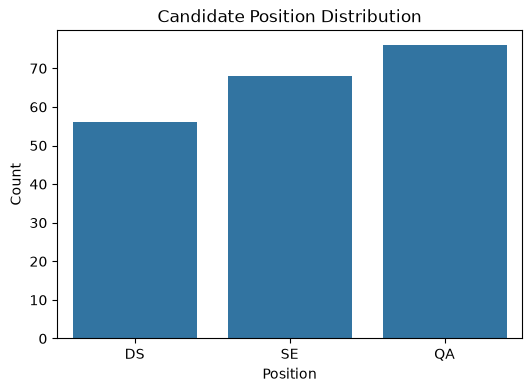

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Position")
plt.title("Candidate Position Distribution")
plt.xlabel("Position")
plt.ylabel("Count")
plt.show()

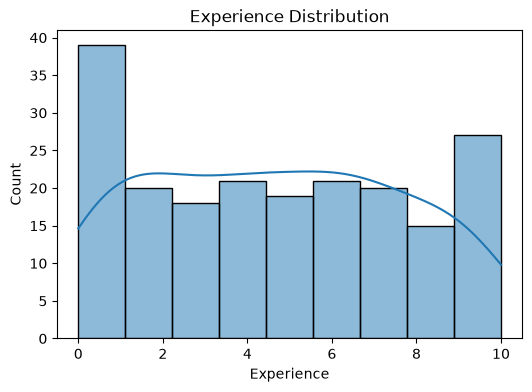

In [17]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Experience"], kde=True)
plt.title("Experience Distribution")
plt.xlabel("Experience")
plt.show()

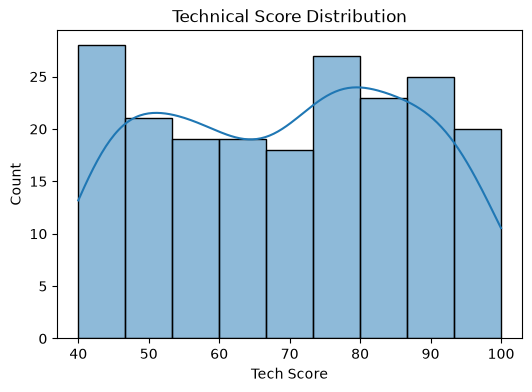

In [18]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Tech_Score"], kde=True)
plt.title("Technical Score Distribution")
plt.xlabel("Tech Score")
plt.show()

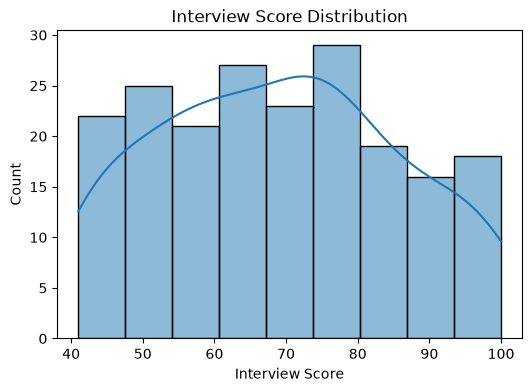

In [19]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Interview"], kde=True)
plt.title("Interview Score Distribution")
plt.xlabel("Interview Score")
plt.show()

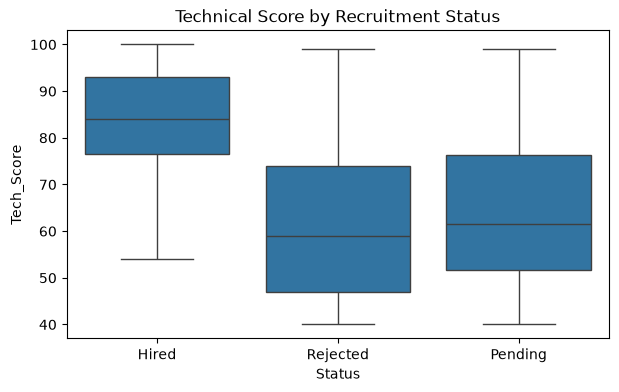

In [20]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Status", y="Tech_Score")
plt.title("Technical Score by Recruitment Status")
plt.show()

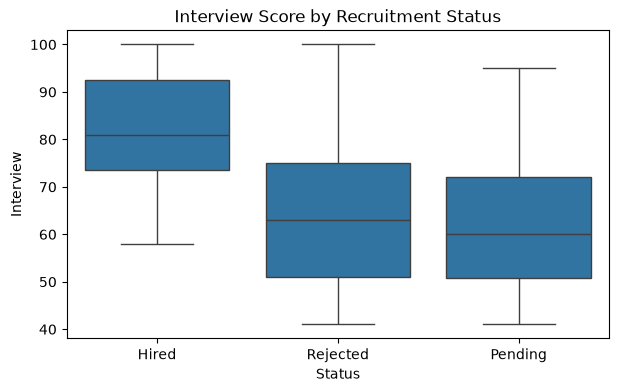

In [21]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Status", y="Interview")
plt.title("Interview Score by Recruitment Status")
plt.show()

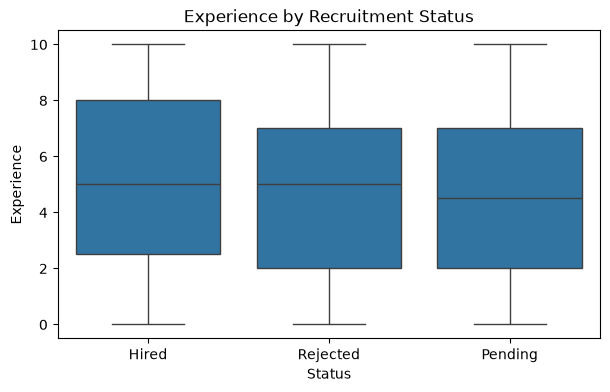

In [22]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Status", y="Experience")
plt.title("Experience by Recruitment Status")
plt.show()

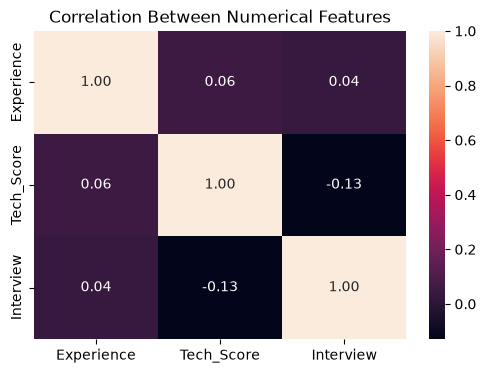

In [23]:
numeric_df = df[["Experience", "Tech_Score", "Interview"]]

plt.figure(figsize=(6, 4))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()